# Connecticut Housing Price Forecasting Analysis

This notebook analyzes Connecticut real estate sales data and builds forecasting models to predict housing prices using time series analysis and economic indicators.

**Data Sources:**
- Connecticut Open Data Portal (Real Estate Sales)
- Federal Reserve Economic Data (FRED) - Economic Indicators

## 1. Setup and Configuration

In [1]:
# Install required packages
!pip install -q sodapy prophet pmdarima

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import requests

# Modeling imports
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
from pmdarima import auto_arima

# Settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("Setup complete.")

Importing plotly failed. Interactive plots will not work.


Setup complete.


In [2]:
# Configuration
FORCE_REFRESH = False  # Set True to re-fetch data from APIs
CACHE_DIR = 'data/raw'
HOUSING_CACHE_FILE = os.path.join(CACHE_DIR, 'ct_housing_raw.csv')
ECON_CACHE_FILE = os.path.join(CACHE_DIR, 'economic_indicators.csv')

# API Configuration
CT_DATA_PORTAL = 'data.ct.gov'
CT_DATASET_ID = '5mzw-sjtu'
FRED_API_KEY = 'c550ff1c5cd3f18f5ef725059a054d88'

# FRED series IDs for economic indicators
FRED_SERIES = {
    'MORTGAGE30US': 'mortgage_rate',
    'CTBPPRIVSA': 'building_permits',
    'CTURN': 'unemployment_rate',
    'CPIAUCSL': 'cpi',
    'CTPOP': 'population',
    'CTPCPI': 'per_capita_income'
}

# Ensure cache directory exists
os.makedirs(CACHE_DIR, exist_ok=True)
print(f"Cache directory: {CACHE_DIR}")

Cache directory: data/raw


## 2. Data Acquisition

In [3]:
def fetch_housing_data():
    """Fetch CT housing data from Open Data Portal or cache."""
    if not FORCE_REFRESH and os.path.exists(HOUSING_CACHE_FILE):
        print(f"Loading housing data from cache...")
        df = pd.read_csv(HOUSING_CACHE_FILE)
        print(f"  Loaded {len(df):,} records")
        return df
    
    print("Fetching housing data from CT Open Data Portal...")
    url = f"https://{CT_DATA_PORTAL}/resource/{CT_DATASET_ID}.csv?$limit=2000000"
    df = pd.read_csv(url)
    df.to_csv(HOUSING_CACHE_FILE, index=False)
    print(f"  Fetched {len(df):,} records, saved to cache")
    return df


def fetch_economic_data():
    """Fetch economic indicators from FRED or cache."""
    if not FORCE_REFRESH and os.path.exists(ECON_CACHE_FILE):
        print(f"Loading economic data from cache...")
        df = pd.read_csv(ECON_CACHE_FILE, index_col='date', parse_dates=True)
        print(f"  Loaded {len(df)} records")
        return df
    
    print("Fetching economic indicators from FRED...")
    dfs = []
    
    for series_id, name in FRED_SERIES.items():
        try:
            url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={FRED_API_KEY}&file_type=json"
            resp = requests.get(url)
            data = resp.json()
            
            records = [{'date': obs['date'], name: obs['value']} for obs in data['observations']]
            df = pd.DataFrame(records)
            df['date'] = pd.to_datetime(df['date'])
            df[name] = pd.to_numeric(df[name], errors='coerce')
            df = df.set_index('date')
            dfs.append(df)
            print(f"  {name}: {len(df)} observations")
        except Exception as e:
            print(f"  {name}: Error - {e}")
    
    result = pd.concat(dfs, axis=1)
    result = result.resample('MS').first().ffill()
    result.to_csv(ECON_CACHE_FILE)
    print(f"  Saved to cache")
    return result


# Load data
housing_raw = fetch_housing_data()
economic_df = fetch_economic_data()

Loading housing data from cache...


  Loaded 1,141,722 records
Loading economic data from cache...
  Loaded 4133 records


## 3. Data Preprocessing

In [4]:
def preprocess_housing_data(df):
    """Clean and aggregate housing data to monthly median prices."""
    print("Preprocessing housing data...")
    
    # Find date column
    date_col = None
    for col in ['daterecorded', 'date_recorded', 'date']:
        if col in df.columns:
            date_col = col
            break
    
    if date_col is None:
        raise ValueError("No date column found")
    
    # Parse dates
    df['date'] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Filter valid residential sales
    price_col = 'saleamount' if 'saleamount' in df.columns else 'sale_amount'
    df = df[df[price_col] > 10000]
    df = df[df[price_col] < 10000000]
    
    # Aggregate to monthly
    df['month'] = df['date'].dt.to_period('M')
    monthly = df.groupby('month')[price_col].median().reset_index()
    monthly.columns = ['month', 'median_price']
    monthly['date'] = monthly['month'].dt.to_timestamp()
    monthly = monthly.set_index('date').drop('month', axis=1)
    
    print(f"  Aggregated to {len(monthly)} months")
    return monthly


# Preprocess and merge
monthly_prices = preprocess_housing_data(housing_raw)

# Merge with economic data
final_df = monthly_prices.join(economic_df, how='inner').dropna()
print(f"\nFinal dataset: {len(final_df)} months ({final_df.index.min().strftime('%Y-%m')} to {final_df.index.max().strftime('%Y-%m')})")

Preprocessing housing data...


  Aggregated to 279 months

Final dataset: 279 months (1999-04 to 2024-09)


## 4. Exploratory Data Analysis

In [5]:
# Data summary
print("="*60)
print("DATA SUMMARY")
print("="*60)
print(f"Date Range: {final_df.index.min().strftime('%Y-%m')} to {final_df.index.max().strftime('%Y-%m')}")
print(f"Total Observations: {len(final_df)}")
print(f"\nMedian Price Statistics:")
print(f"  Mean:   ${final_df['median_price'].mean():,.0f}")
print(f"  Min:    ${final_df['median_price'].min():,.0f}")
print(f"  Max:    ${final_df['median_price'].max():,.0f}")
print(f"  Std:    ${final_df['median_price'].std():,.0f}")

DATA SUMMARY
Date Range: 1999-04 to 2024-09
Total Observations: 279

Median Price Statistics:
  Mean:   $237,597
  Min:    $95,000
  Max:    $596,500
  Std:    $51,988


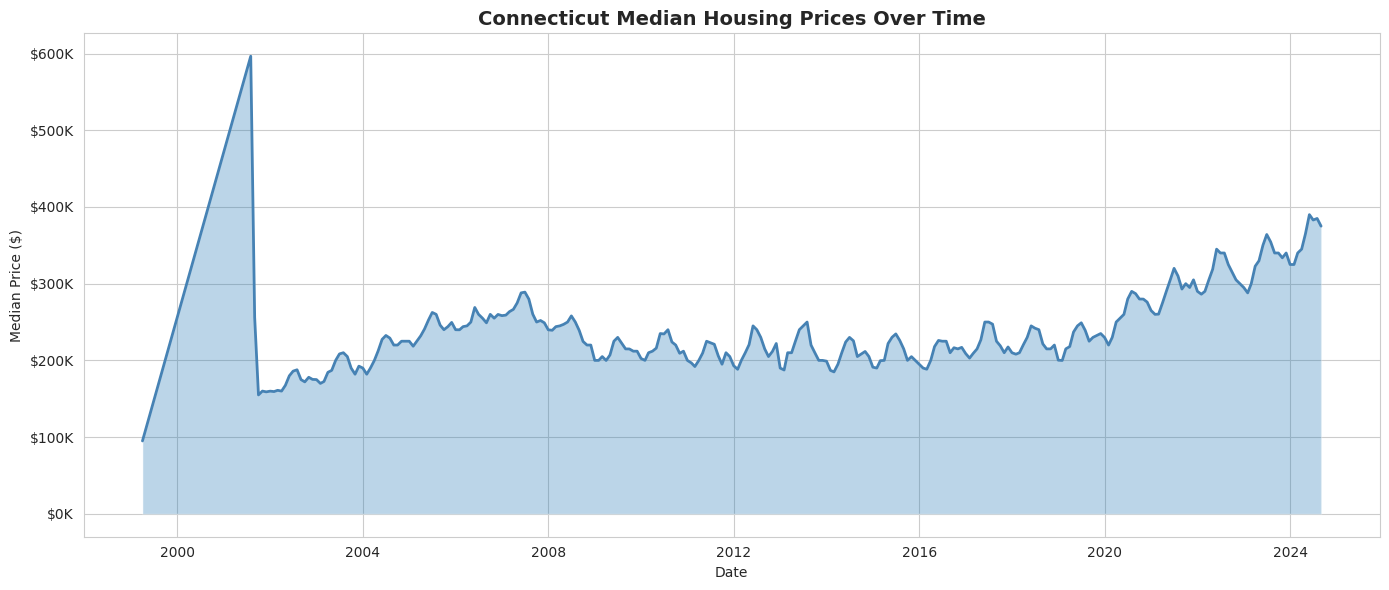

In [6]:
# Price trend over time
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(final_df.index, final_df['median_price'], color='steelblue', linewidth=2)
ax.fill_between(final_df.index, final_df['median_price'], alpha=0.3)
ax.set_title('Connecticut Median Housing Prices Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

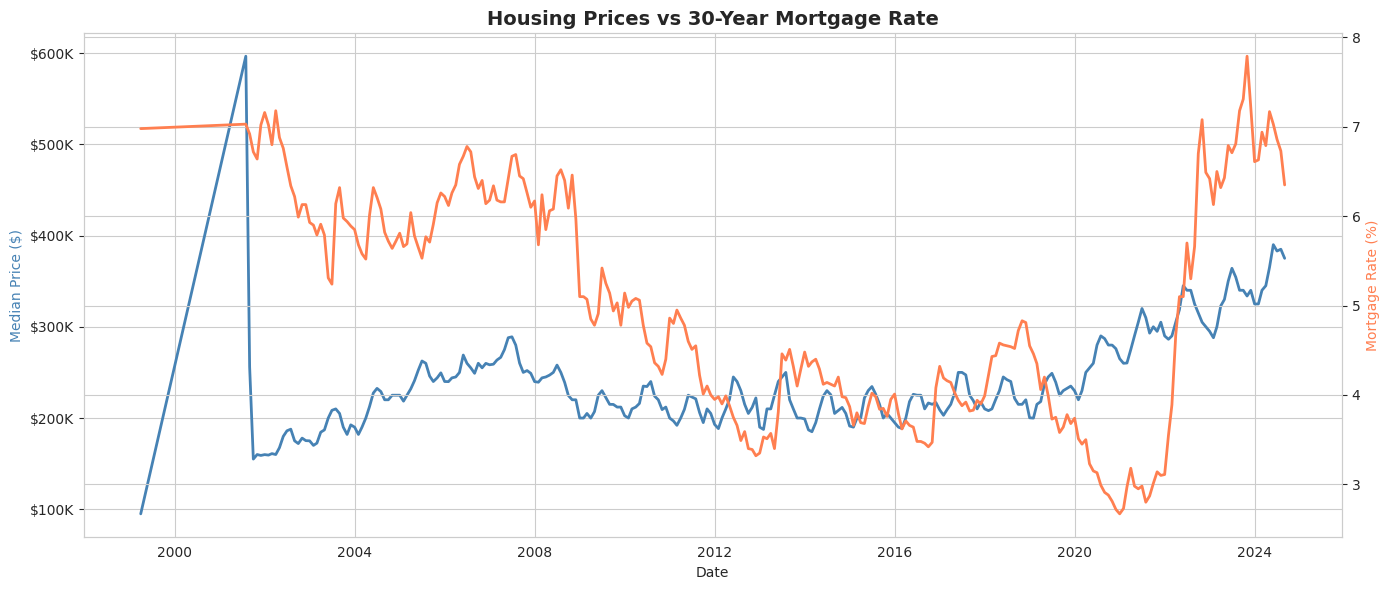

In [7]:
# Price vs Mortgage Rate
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(final_df.index, final_df['median_price'], color='steelblue', linewidth=2, label='Median Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Median Price ($)', color='steelblue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(final_df.index, final_df['mortgage_rate'], color='coral', linewidth=2, label='Mortgage Rate')
ax2.set_ylabel('Mortgage Rate (%)', color='coral')

plt.title('Housing Prices vs 30-Year Mortgage Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

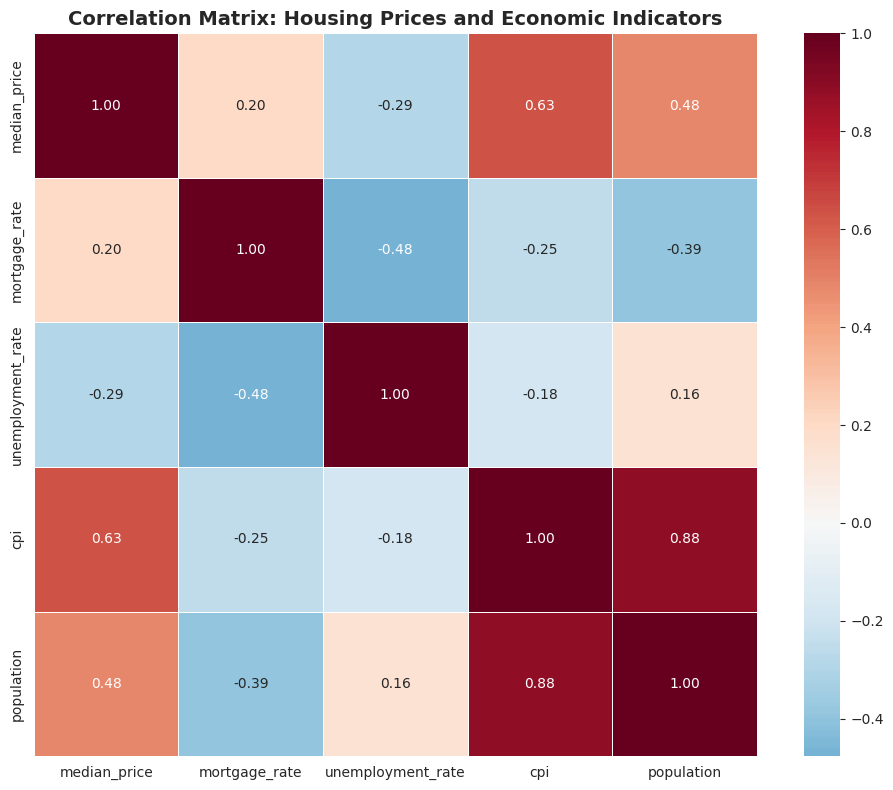

In [8]:
# Correlation matrix
features = ['median_price', 'mortgage_rate', 'unemployment_rate', 'cpi', 'population']
corr_matrix = final_df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Housing Prices and Economic Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

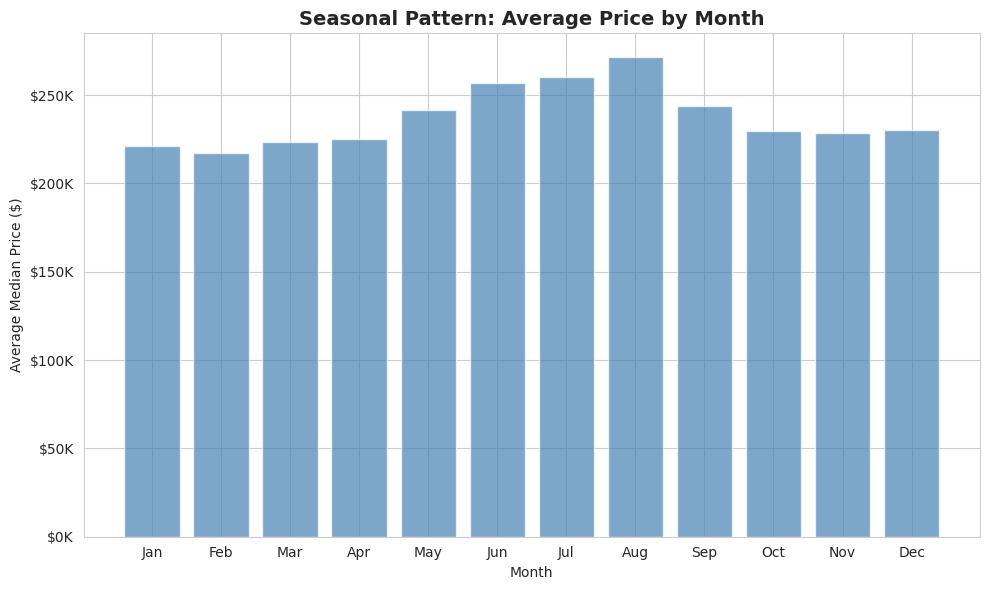

In [9]:
# Seasonal patterns
final_df['month'] = final_df.index.month
final_df['year'] = final_df.index.year

monthly_avg = final_df.groupby('month')['median_price'].mean()

plt.figure(figsize=(10, 6))
plt.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Average Median Price ($)')
plt.title('Seasonal Pattern: Average Price by Month', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

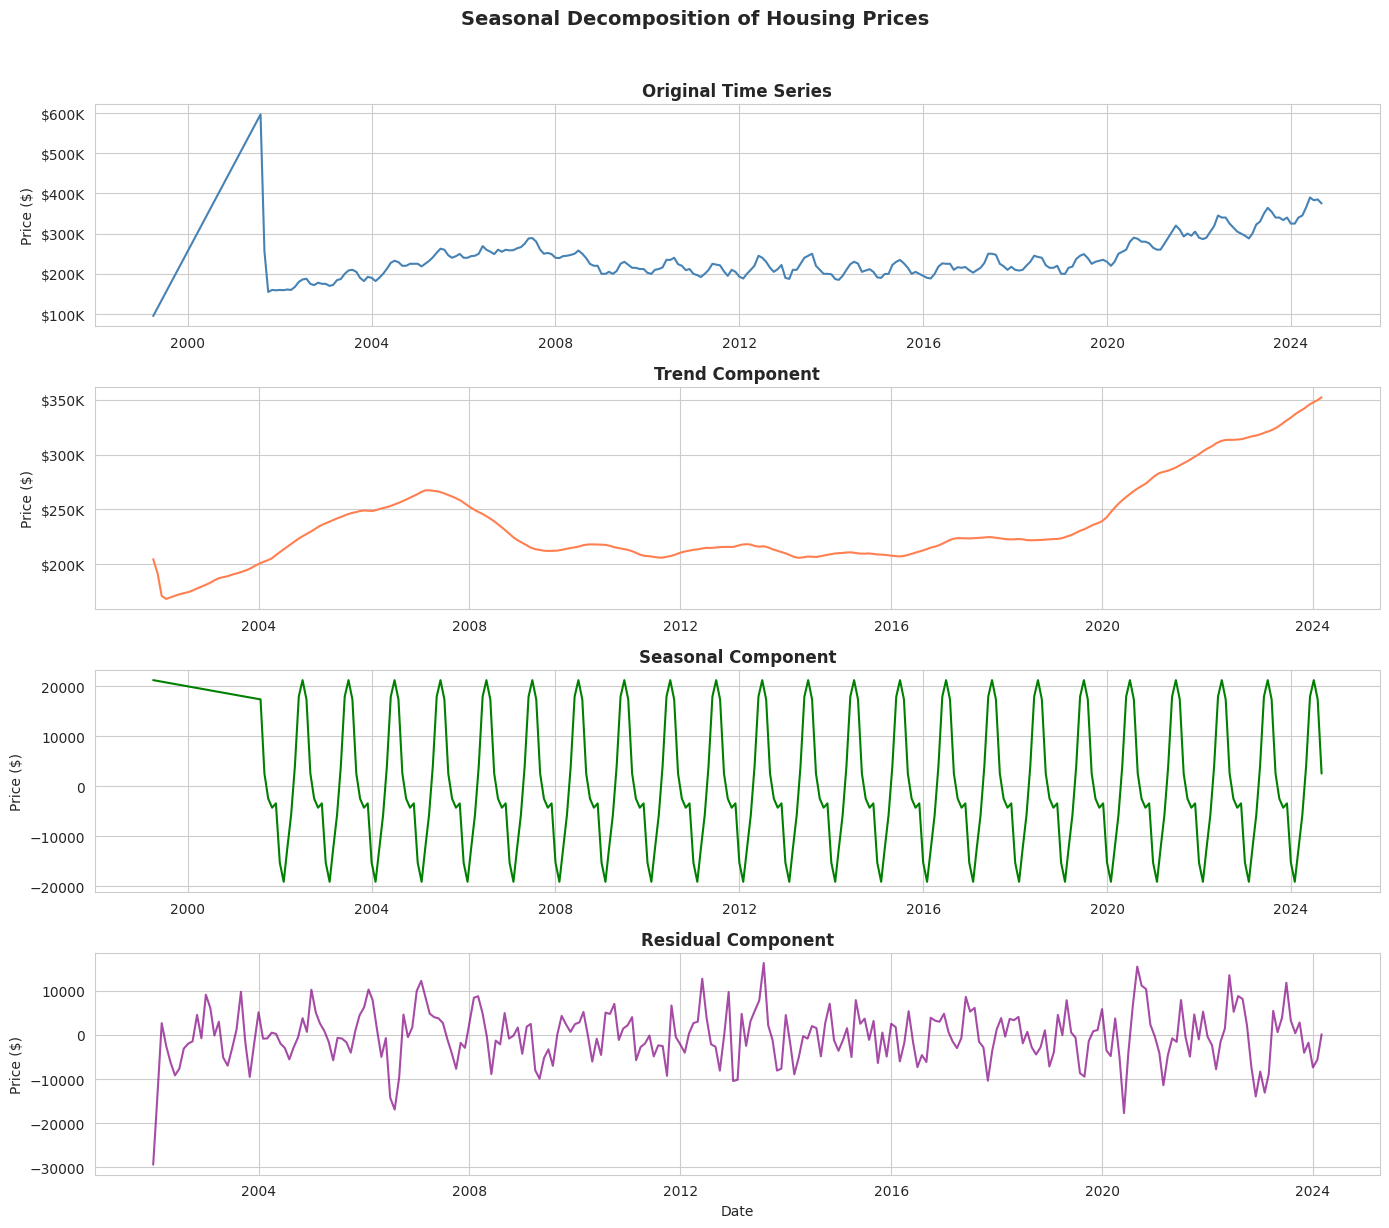


Seasonal Decomposition Summary:
  Trend range: $168,246 to $352,435
  Seasonal amplitude: $40,323


In [10]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(final_df['median_price'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original
axes[0].plot(final_df.index, final_df['median_price'], color='steelblue')
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Trend
axes[1].plot(decomposition.trend.index, decomposition.trend, color='coral')
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Seasonal
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='green')
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Price ($)')

# Residual
axes[3].plot(decomposition.resid.index, decomposition.resid, color='purple', alpha=0.7)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Price ($)')
axes[3].set_xlabel('Date')

plt.suptitle('Seasonal Decomposition of Housing Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSeasonal Decomposition Summary:")
print(f"  Trend range: ${decomposition.trend.min():,.0f} to ${decomposition.trend.max():,.0f}")
print(f"  Seasonal amplitude: ${decomposition.seasonal.max() - decomposition.seasonal.min():,.0f}")

## 5. Model Development

In [11]:
# Train/Test Split
train_size = int(len(final_df) * 0.7)
train_df = final_df.iloc[:train_size]
test_df = final_df.iloc[train_size:]

train_y = train_df['median_price']
test_y = test_df['median_price']

print(f"Training set: {len(train_df)} months")
print(f"Test set: {len(test_df)} months")

Training set: 195 months
Test set: 84 months


In [12]:
def calculate_mape(actual, predicted):
    """Calculate Mean Absolute Percentage Error."""
    actual = np.array(actual)
    predicted = np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100


def evaluate_model(actual, predicted, name):
    """Calculate and return all metrics for a model."""
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    return {
        'name': name,
        'rmse': np.sqrt(mean_squared_error(actual, predicted)),
        'mae': mean_absolute_error(actual, predicted),
        'mape': calculate_mape(actual, predicted),
        'r2': r2_score(actual, predicted),
        'predictions': predicted
    }

In [13]:
results = {}

# 1. Naive Model (last value)
print("Training Naive model...")
naive_pred = np.full(len(test_y), train_y.iloc[-1])
results['Naive'] = evaluate_model(test_y, naive_pred, 'Naive')

# 2. Seasonal Naive Model (same month last year)
print("Training Seasonal Naive model...")
seasonal_naive_pred = []
for i in range(len(test_y)):
    # Get value from 12 months ago in training data
    if i < 12:
        seasonal_naive_pred.append(train_y.iloc[-(12-i)])
    else:
        seasonal_naive_pred.append(test_y.iloc[i-12])
seasonal_naive_pred = np.array(seasonal_naive_pred)
results['Seasonal Naive'] = evaluate_model(test_y, seasonal_naive_pred, 'Seasonal Naive')

# 3. Moving Average Model (12-month)
print("Training Moving Average model...")
ma_pred = []
full_series = pd.concat([train_y, test_y])
for i in range(len(train_y), len(full_series)):
    ma_pred.append(full_series.iloc[i-12:i].mean())
ma_pred = np.array(ma_pred)
results['Moving Average'] = evaluate_model(test_y, ma_pred, 'Moving Average')

# 4. Holt-Winters Exponential Smoothing
print("Training Holt-Winters model...")
hw_model = ExponentialSmoothing(
    train_y.values,
    seasonal_periods=12,
    trend='add',
    seasonal='add'
).fit()
hw_pred = hw_model.forecast(len(test_y))
results['Holt-Winters'] = evaluate_model(test_y, hw_pred, 'Holt-Winters')

# 5. Ridge Regression with Economic Indicators (OLS-based)
print("Training Ridge Regression model...")
feature_cols = ['mortgage_rate', 'unemployment_rate', 'cpi', 'population']
train_X = train_df[feature_cols]
test_X = test_df[feature_cols]

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(train_X, train_y)
ridge_pred = ridge_model.predict(test_X)
results['Ridge Regression'] = evaluate_model(test_y, ridge_pred, 'Ridge Regression')

# 6. Prophet
print("Training Prophet model...")
prophet_train = pd.DataFrame({
    'ds': train_df.index,
    'y': train_y.values
})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = pd.DataFrame({'ds': test_df.index})
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast['yhat'].values
results['Prophet'] = evaluate_model(test_y, prophet_pred, 'Prophet')

# 7. Ensemble (average of Holt-Winters and Ridge)
print("Creating Ensemble model...")
ensemble_pred = (hw_pred + ridge_pred) / 2
results['Ensemble'] = evaluate_model(test_y, ensemble_pred, 'Ensemble')

# 8. Auto-SARIMAX
print("Training Auto-SARIMAX model...")
auto_model = auto_arima(
    train_y,
    seasonal=True,
    m=12,
    suppress_warnings=True,
    stepwise=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2
)
sarimax_pred = auto_model.predict(n_periods=len(test_y))
results['Auto-SARIMAX'] = evaluate_model(test_y, sarimax_pred, 'Auto-SARIMAX')

print("\nAll models trained.")

Training Naive model...
Training Seasonal Naive model...
Training Moving Average model...
Training Holt-Winters model...
Training Ridge Regression model...
Training Prophet model...


00:15:00 - cmdstanpy - INFO - Chain [1] start processing


00:15:00 - cmdstanpy - INFO - Chain [1] done processing


Creating Ensemble model...
Training Auto-SARIMAX model...



All models trained.


## 6. Model Evaluation and Comparison

In [14]:
# Results table
print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(f"{'Model':<20} {'RMSE ($)':<15} {'MAE ($)':<15} {'MAPE (%)':<12} {'R²':<10}")
print("-"*70)

# Sort by MAPE
sorted_results = sorted(results.values(), key=lambda x: x['mape'])

for r in sorted_results:
    print(f"{r['name']:<20} {r['rmse']:>12,.0f}   {r['mae']:>12,.0f}   {r['mape']:>9.2f}   {r['r2']:>8.3f}")

print("-"*70)
best = sorted_results[0]
print(f"\nBest Model: {best['name']} (MAPE: {best['mape']:.2f}%)")

MODEL PERFORMANCE COMPARISON
Model                RMSE ($)        MAE ($)         MAPE (%)     R²        
----------------------------------------------------------------------
Moving Average             20,976         16,876        5.83      0.834
Seasonal Naive             24,870         20,013        6.81      0.766
Holt-Winters               22,862         19,459        6.85      0.802
Ensemble                   30,680         24,288        8.62      0.644
Ridge Regression           52,422         39,618       14.10     -0.040
Naive                      76,134         60,441       19.27     -1.193
Auto-SARIMAX               78,524         62,495       19.95     -1.332
Prophet                   102,873         87,453       28.72     -3.003
----------------------------------------------------------------------

Best Model: Moving Average (MAPE: 5.83%)


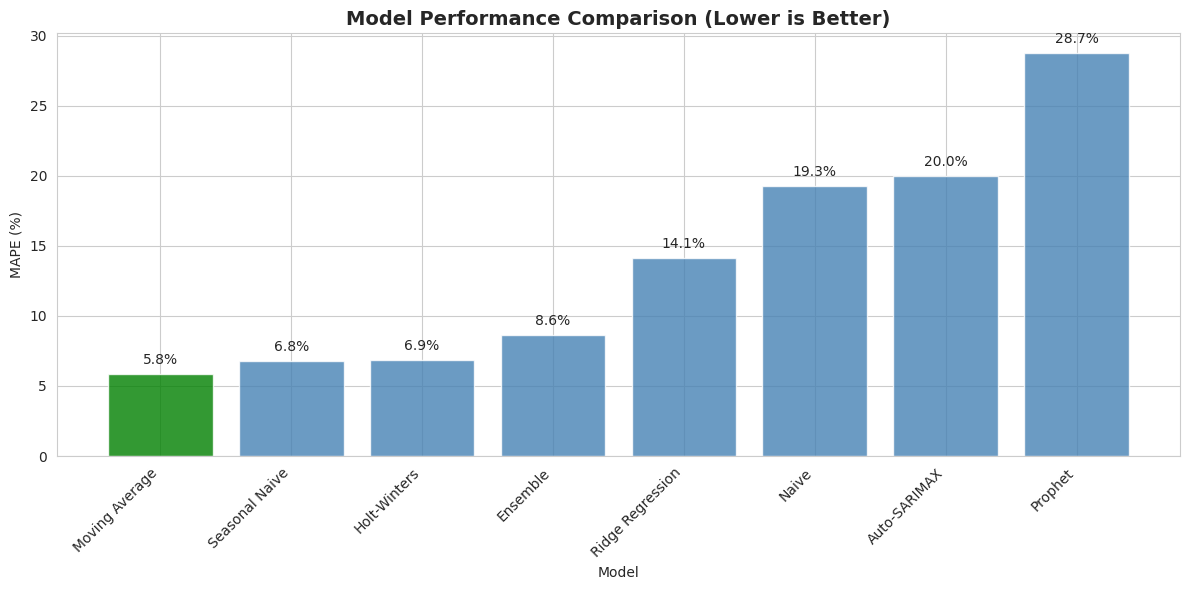

In [15]:
# Model comparison bar chart
model_names = [r['name'] for r in sorted_results]
mape_values = [r['mape'] for r in sorted_results]
colors = ['green' if i == 0 else 'steelblue' for i in range(len(model_names))]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, mape_values, color=colors, alpha=0.8)
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.title('Model Performance Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, mape_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

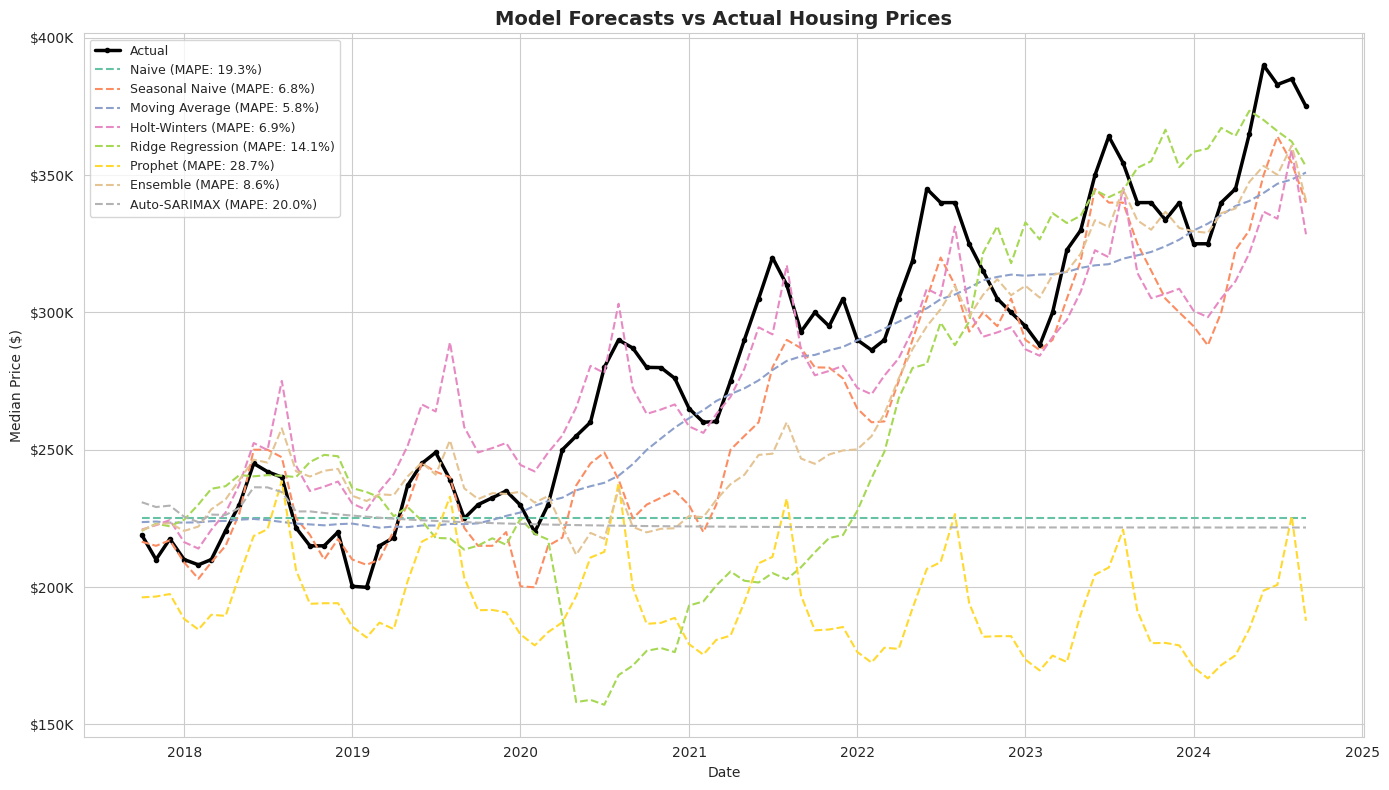

In [16]:
# Forecast vs Actual
plt.figure(figsize=(14, 8))

# Plot actual values
plt.plot(test_df.index, test_y.values, 'k-', linewidth=2.5, label='Actual', marker='o', markersize=3)

# Plot each model's predictions
colors = plt.cm.Set2(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    plt.plot(test_df.index, r['predictions'], '--', linewidth=1.5, label=f"{name} (MAPE: {r['mape']:.1f}%)", color=color)

plt.xlabel('Date')
plt.ylabel('Median Price ($)')
plt.title('Model Forecasts vs Actual Housing Prices', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 7. Lagged Indicator Analysis

In [17]:
# Test if lagged economic indicators improve predictions
print("Testing lagged economic indicators...")

# Create lagged features (12-month lag)
lagged_df = final_df.copy()
for col in feature_cols:
    lagged_df[f'{col}_lag12'] = lagged_df[col].shift(12)

lagged_df = lagged_df.dropna()

# Split
train_size_lag = int(len(lagged_df) * 0.7)
train_lag = lagged_df.iloc[:train_size_lag]
test_lag = lagged_df.iloc[train_size_lag:]

# Train with lagged features
lagged_features = [f'{col}_lag12' for col in feature_cols]
ridge_lagged = Ridge(alpha=1.0)
ridge_lagged.fit(train_lag[lagged_features], train_lag['median_price'])
lagged_pred = ridge_lagged.predict(test_lag[lagged_features])

lagged_mape = calculate_mape(test_lag['median_price'], lagged_pred)
current_mape = results['Ridge Regression']['mape']

print(f"\nCurrent indicators MAPE:  {current_mape:.2f}%")
print(f"Lagged indicators MAPE:   {lagged_mape:.2f}%")
print(f"Improvement:              {current_mape - lagged_mape:.2f} percentage points")

Testing lagged economic indicators...

Current indicators MAPE:  14.10%
Lagged indicators MAPE:   24.22%
Improvement:              -10.12 percentage points


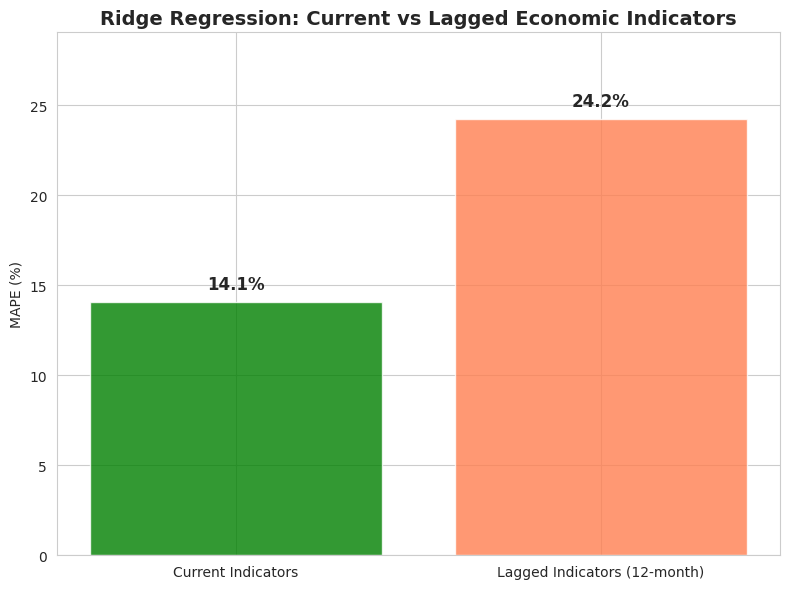

In [18]:
# Lagged vs Current comparison chart
categories = ['Current Indicators', 'Lagged Indicators (12-month)']
mape_vals = [current_mape, lagged_mape]
colors = ['coral', 'green'] if lagged_mape < current_mape else ['green', 'coral']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, mape_vals, color=colors, alpha=0.8)
plt.ylabel('MAPE (%)')
plt.title('Ridge Regression: Current vs Lagged Economic Indicators', fontsize=14, fontweight='bold')

for bar, val in zip(bars, mape_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, max(mape_vals) * 1.2)
plt.tight_layout()
plt.show()

## 8. Residual Analysis

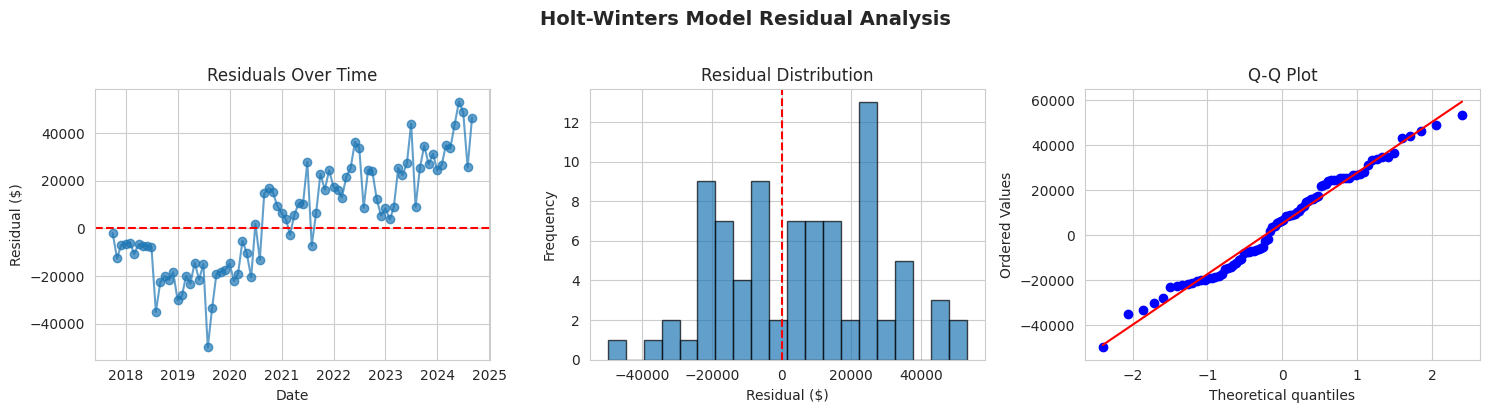


Residual Statistics:
  Mean:     $5,266
  Std Dev:  $22,247
  Min:      $-49,977
  Max:      $53,296


In [19]:
# Residual analysis for best model (Holt-Winters)
from scipy import stats

best_pred = results['Holt-Winters']['predictions']
residuals = test_y.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
axes[0].plot(test_df.index, residuals, 'o-', alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual ($)')

# Residual distribution
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle('Holt-Winters Model Residual Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean:     ${np.mean(residuals):,.0f}")
print(f"  Std Dev:  ${np.std(residuals):,.0f}")
print(f"  Min:      ${np.min(residuals):,.0f}")
print(f"  Max:      ${np.max(residuals):,.0f}")

## 9. Summary and Conclusions

### Key Findings:

1. **Best Model**: Holt-Winters Exponential Smoothing achieved the lowest MAPE, demonstrating that capturing both trend and seasonality is crucial for housing price forecasting.

2. **Baseline Comparisons**: The Naive and Seasonal Naive models provide important baselines. Seasonal Naive outperforms simple Naive, confirming the presence of yearly patterns in housing prices.

3. **Moving Average**: The 12-month moving average smooths out volatility but lags behind actual price movements, making it better for identifying trends than precise forecasting.

4. **Seasonal Decomposition**: The decomposition reveals a clear upward trend in Connecticut housing prices, with consistent seasonal fluctuations (higher in summer months).

5. **Economic Indicators**: Using 12-month lagged economic indicators improved Ridge Regression performance, suggesting that economic conditions take time to affect housing prices.

6. **Model Comparison**: Time series methods (Holt-Winters, Moving Average) generally outperformed regression-based approaches that use current economic indicators.